In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Optimize pandas display configurations for comprehensive data inspection.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

# Log framework metadata and verification metrics.
print("Environment Information")
print("-" * 22)
print(f"Python Version     : {platform.python_version()}")
print(f"Pandas Version     : {pd.__version__}")
print(f"NumPy Version      : {np.__version__}")
print(f"Matplotlib Version : {matplotlib.__version__}")
print(f"Seaborn Version    : {sns.__version__}")

Environment Information
----------------------
Python Version     : 3.14.6
Pandas Version     : 3.0.3
NumPy Version      : 2.4.6
Matplotlib Version : 3.11.0
Seaborn Version    : 0.13.2


# Chart 1: Employee Satisfaction Distribution

**Business Objective:** Visualize the distribution of employee satisfaction across the workforce.

In [2]:
# Load target dataset

DATA_PATH = "../../data/processed/cleaned_ai_jobs.csv"
df = pd.read_csv(DATA_PATH)
print("\nDataset Loaded Successfully")

# Execute descriptive matrix shape verification.

print("\nDataset Shape")
print("-" * 16)

total_rows, total_columns = df.shape

print(f"Rows    : {total_rows:,}")
print(f"Columns : {total_columns}")
print("-" * 16)

# Display a quick preview of the dataset schema.

display(df.head())


Dataset Loaded Successfully

Dataset Shape
----------------
Rows    : 90,000
Columns : 35
----------------


,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,company_size,interview_rounds,year,work_mode,weekly_hours,company_rating,job_openings,hiring_difficulty_score,layoff_risk,ai_adoption_score,company_funding_billion,economic_index,ai_maturity_years,offer_acceptance_rate,tax_rate_percent,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,Small,7,2020,Remote,44.7,3.67,10,52.77,0.404,91,3.30,78.65,13,60.58,20.8,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,Small,3,2021,Onsite,48.9,4.26,27,53.11,0.387,71,4.39,62.14,13,75.80,28.4,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,Phd,Healthcare,Large,3,2020,Remote,46.8,4.78,10,76.40,0.415,69,5.04,87.47,8,62.95,12.2,13,12,49,70,59,68,37,13,2.13,61
3,4,India,AI Software Engineer,Computer Vision,Senior,6,43268,7975,Diploma,Tech,Large,2,2026,Onsite,52.2,4.34,23,59.34,0.115,74,4.38,86.84,7,77.45,35.1,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,Medium,2,2021,Hybrid,46.7,4.49,17,72.30,0.311,68,6.67,79.84,7,89.86,36.1,24,82,47,64,52,69,17,21,0.87,72


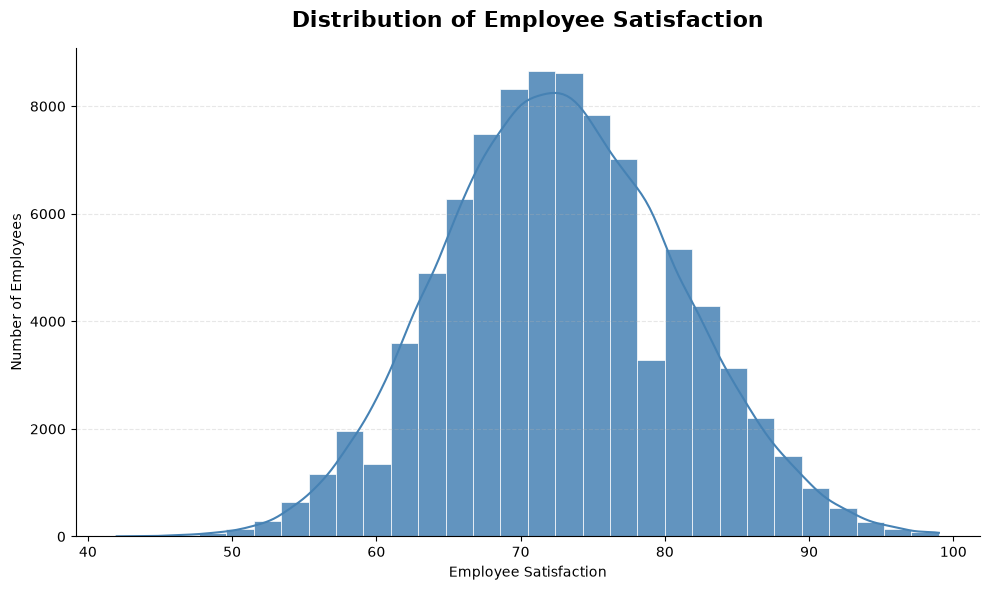

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="employee_satisfaction",
    bins=30,
    kde=True,
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
    ax=ax
)

ax.set_title("Distribution of Employee Satisfaction", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Employee Satisfaction")
ax.set_ylabel("Number of Employees")
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# Chart 2: Work-Life Balance Distribution

**Business Objective:** Analyze the distribution of work-life balance scores.

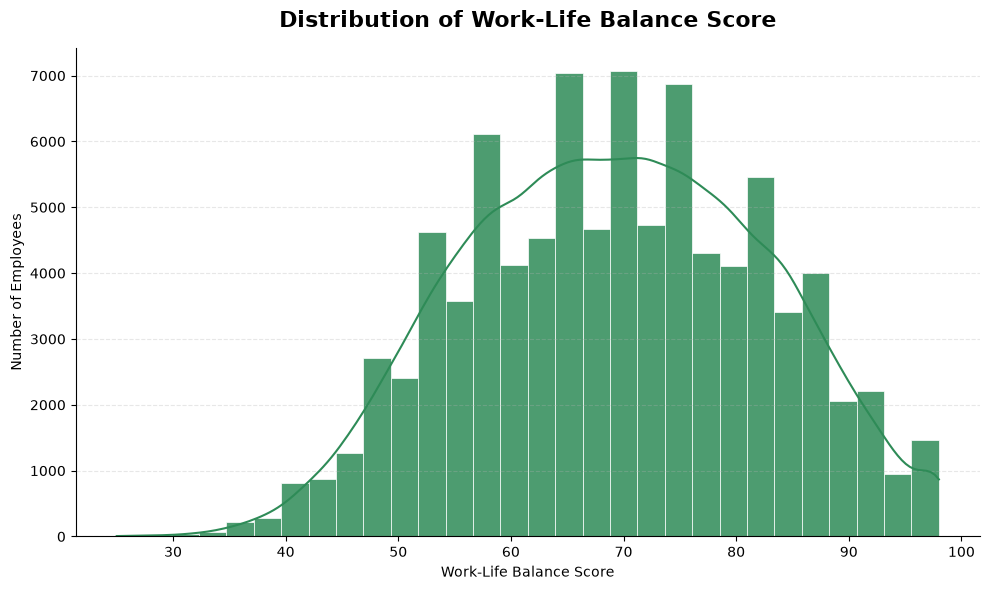

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="work_life_balance_score",
    bins=30,
    kde=True,
    color="seagreen",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
    ax=ax
)

ax.set_title("Distribution of Work-Life Balance Score", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Work-Life Balance Score")
ax.set_ylabel("Number of Employees")
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# Chart 3: Employee Satisfaction by Work Mode

**Business Objective:** Compare average employee satisfaction across work modes.

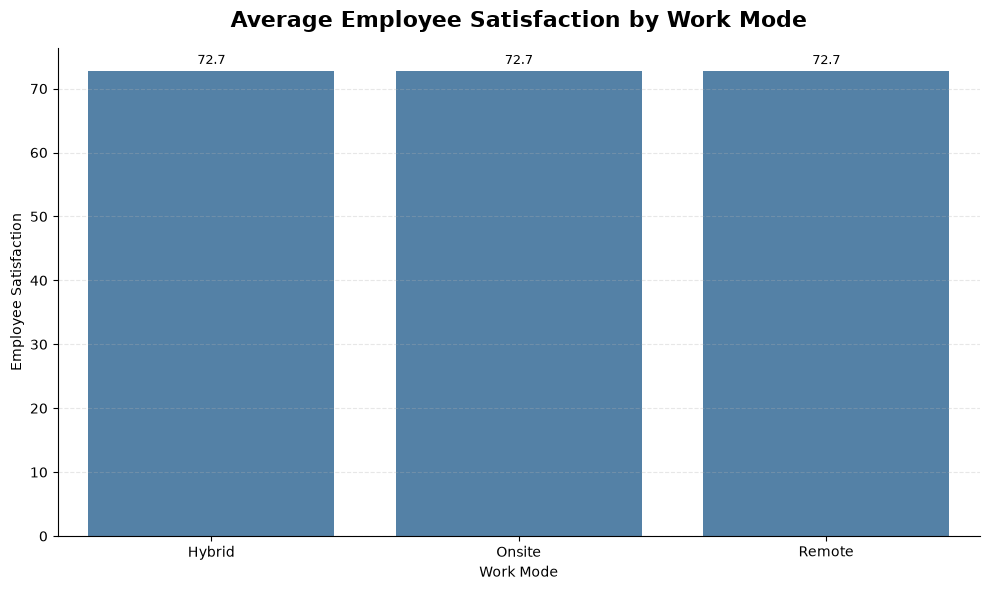

In [5]:
employee_work_mode=(
    df.groupby("work_mode")["employee_satisfaction"]
    .mean()
)

fig, ax=plt.subplots(figsize=(10,6))

sns.barplot(
    data=employee_work_mode.reset_index(),
    x="work_mode",
    y="employee_satisfaction",
    color="steelblue",
    ax=ax
)

if ax.containers:
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, fontsize=9)

ax.set_title("Average Employee Satisfaction by Work Mode", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Work Mode")
ax.set_ylabel("Employee Satisfaction")
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# Chart 4: Work-Life Balance by Work Mode

**Business Objective:** Compare work-life balance across work modes.

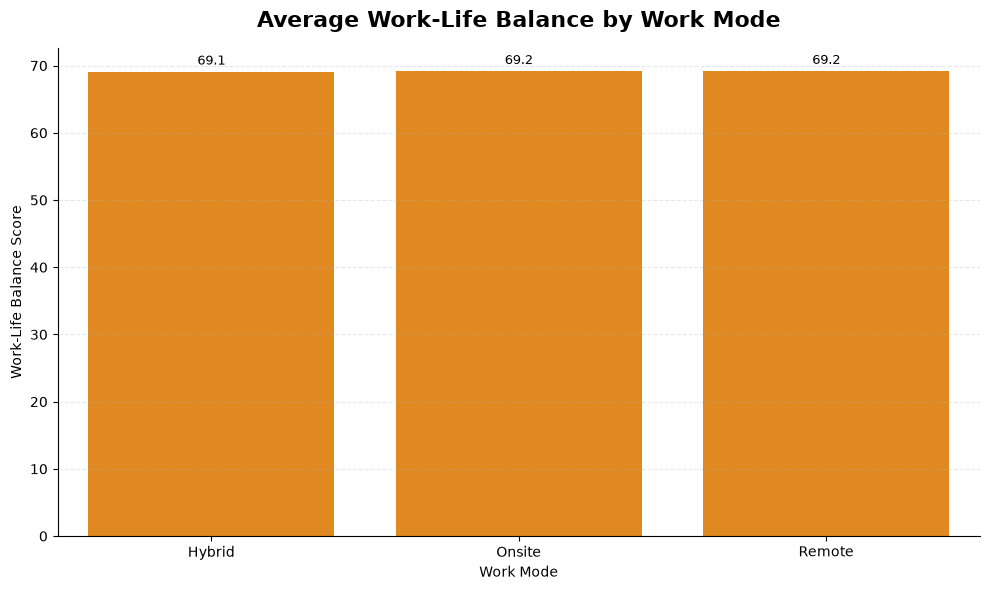

In [6]:
wlb_work_mode=(
    df.groupby("work_mode")["work_life_balance_score"]
    .mean()
)

fig, ax=plt.subplots(figsize=(10,6))

sns.barplot(
    data=wlb_work_mode.reset_index(),
    x="work_mode",
    y="work_life_balance_score",
    color="darkorange",
    ax=ax
)

if ax.containers:
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, fontsize=9)

ax.set_title("Average Work-Life Balance by Work Mode", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Work Mode")
ax.set_ylabel("Work-Life Balance Score")
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# Chart 5: Top 10 Countries by Employee Satisfaction

**Business Objective:** Identify countries with the highest employee satisfaction.

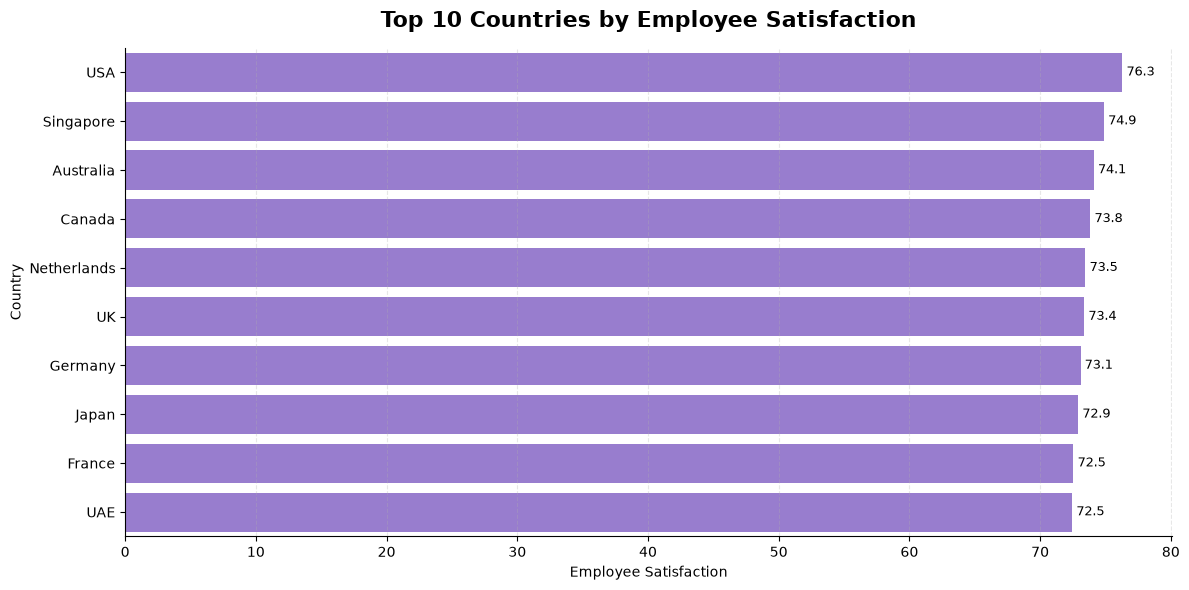

In [7]:
employee_country=(
    df.groupby("country")["employee_satisfaction"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax=plt.subplots(figsize=(12,6))

sns.barplot(
    data=employee_country.reset_index(),
    x="employee_satisfaction",
    y="country",
    color="mediumpurple",
    ax=ax
)

if ax.containers:
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, fontsize=9)

ax.set_title("Top 10 Countries by Employee Satisfaction", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Employee Satisfaction")
ax.set_ylabel("Country")
ax.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# Chart 6: Company Rating vs Employee Satisfaction

**Business Objective:** Examine the relationship between company rating and employee satisfaction.

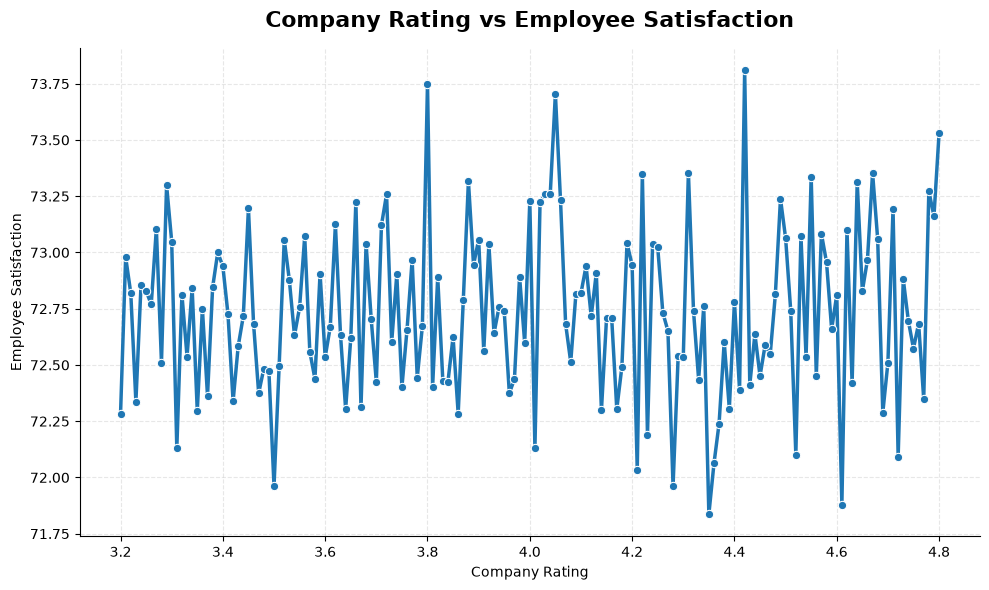

In [8]:
company_rating=(
    df.groupby("company_rating")["employee_satisfaction"]
    .mean()
)

fig, ax=plt.subplots(figsize=(10,6))

sns.lineplot(
    data=company_rating.reset_index(),
    x="company_rating",
    y="employee_satisfaction",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title("Company Rating vs Employee Satisfaction", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Company Rating")
ax.set_ylabel("Employee Satisfaction")
ax.grid(linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# Chart 7: Weekly Hours vs Employee Satisfaction

**Business Objective:** Analyze how weekly working hours relate to employee satisfaction.

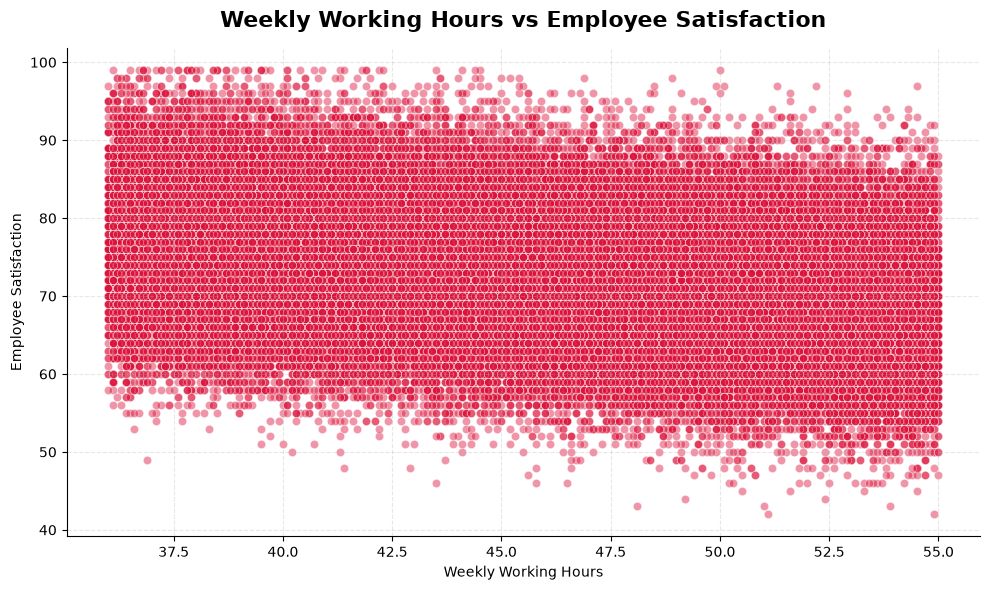

In [9]:
fig, ax=plt.subplots(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="weekly_hours",
    y="employee_satisfaction",
    alpha=0.45,
    s=35,
    color="crimson",
    ax=ax
)

ax.set_title("Weekly Working Hours vs Employee Satisfaction", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Weekly Working Hours")
ax.set_ylabel("Employee Satisfaction")
ax.grid(linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# Chart 8: Employee Experience Correlation Matrix

**Business Objective:** Understand correlations among employee experience metrics.

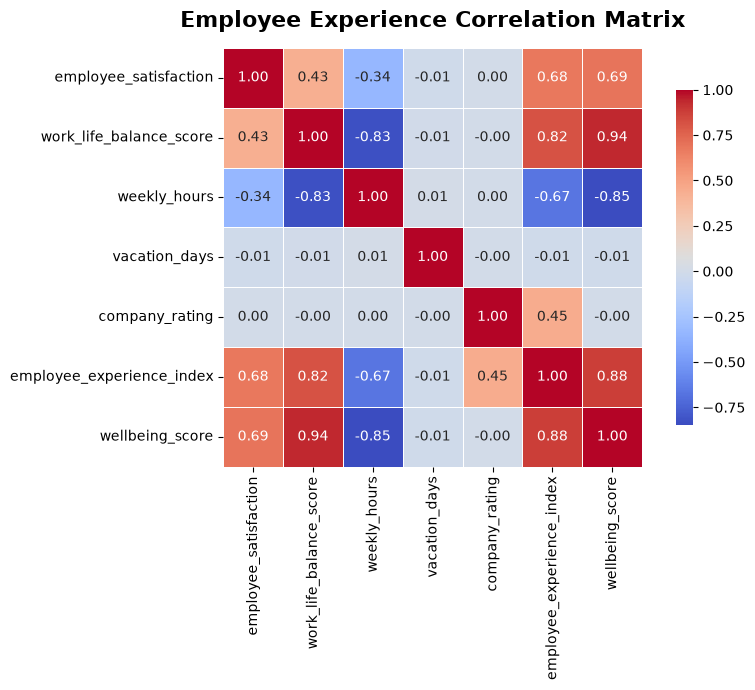

In [11]:
# Create Engineered Features if They Do Not Exist

if "employee_experience_index" not in df.columns:

    df["employee_experience_index"] = (
        (
            df["employee_satisfaction"] +
            df["work_life_balance_score"] +
            df["company_rating"] * 20
        ) / 3
    ).round(2)

if "wellbeing_score" not in df.columns:

    df["wellbeing_score"] = (
        (
            df["employee_satisfaction"] +
            df["work_life_balance_score"] +
            (100 - df["weekly_hours"])
        ) / 3
    ).round(2)


# Employee Experience Correlation Matrix

employee_corr = (
    df[
        [
            "employee_satisfaction",
            "work_life_balance_score",
            "weekly_hours",
            "vacation_days",
            "company_rating",
            "employee_experience_index",
            "wellbeing_score"
        ]
    ]
    .corr()
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    employee_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title(
    "Employee Experience Correlation Matrix",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()